# Рекомендации на главной: эксперименты с моделями

Дипломный проект SkillFactory

**Рубинштейн Андрей**

В прошлом ноутбуке разобрал данные, построил валидацию по времени и посчитал 37 факторов для пар пользователь-товар. Теперь задача от Тимофея: прогнать модели и выбить лучшее качество на тесте по Precision@3

Серёга просил опираться на его генератор факторов. Из него беру топ-20 свойств товаров и деление суток на части (Dawn, Morning, Afternoon, Evening, Night) и проверяю, дают ли они что-то моделям. Разбиение у Серёги тоже по времени, `train_test_split` без перемешивания. У меня то же самое, только срезами по неделям, как договорились на прошлой неделе

Код факторов из прошлого ноутбука я вынес в пакет `recsys/`, чтобы им пользовались и ноутбуки, и сервис. Пакет собирает те же таблицы один в один, проверил на всех шести срезах

Разделы: [метрика](#sec-metric), [популярное](#sec-pop), [эвристика](#sec-heur), [ALS](#sec-als), [item-based](#sec-ib), [LightFM](#sec-lfm), [CatBoost](#sec-cb), [тест](#sec-test), [модель для сервиса](#sec-final), [итоги](#sec-sum)

In [1]:
import warnings

# при импорте implicit и LightFM ругаются на ipywidgets и OpenMP,
# на расчёты это не влияет
warnings.filterwarnings("ignore", message="IProgress not found")
warnings.filterwarnings("ignore", message="LightFM was compiled without OpenMP")

In [2]:
%matplotlib inline
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.sparse as sp
import seaborn as sns
from catboost import CatBoostClassifier, Pool
from implicit.als import AlternatingLeastSquares
from lightfm import LightFM

from recsys.data import load_events
from recsys.features import (
    CUTS,
    FEATURE_DESC,
    FEATURES,
    HIST_DAYS,
    popular_items,
    purchases,
)
from recsys.metrics import fill_with, precision_at_k, purchase_coverage
from recsys.model import CAT_FEATURES, cap_candidates, top_k


RAW = Path("data/raw")
OUT = Path("data/processed")
REPORTS = Path("reports")
REPORTS.mkdir(exist_ok=True)
SEED = 42

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
COLOR = "steelblue"

events = load_events(RAW)
pairs = {split: pd.read_parquet(OUT / f"pairs_{split}.parquet") for split in CUTS}
all_cuts = [cut for cuts in CUTS.values() for cut in cuts]
split_of = {cut: split for split, cuts in CUTS.items() for cut in cuts}
valid_cut, test_cut = CUTS["valid"][0], CUTS["test"][0]

print("событий:", len(events))
print({split: df.shape for split, df in pairs.items()})

событий: 2755641
{'train': (144870, 42), 'valid': (35744, 42), 'test': (35121, 42)}


<a id="sec-metric"></a>

## 1. Как считаю качество

На главной три места, поэтому Precision@3: какая доля из трёх показанных товаров куплена за неделю после среза. Считаю по всем, кто купил на этой неделе. Если персонально показать нечего или своих товаров меньше трёх, свободные места добиваю популярным. Так метрика честная для всего магазина, а не только для тех, у кого есть история

Отдельно смотрю тех же покупателей, но только с историей за 8 недель, дальше зову их тёплыми. Вся разница между моделями живёт у них: холодным любая модель покажет одно и то же популярное

Сначала потолок. Представим модель, которая из истории человека безошибочно выбирает купленное

In [3]:
bought = {cut: purchases(events, cut) for cut in all_cuts}
fallback = {cut: popular_items(events, cut) for cut in all_cuts}

rows = []
for cut in all_cuts:
    part = pairs[split_of[cut]]
    part = part[part["cut"] == cut]
    history_items = part.groupby("visitorid")["itemid"].agg(set).to_dict()
    buyers = bought[cut]
    warm = [u for u in buyers if u in history_items]
    ideal = {
        u: list(items & history_items.get(u, set())) for u, items in buyers.items()
    }
    rows.append(
        {
            "срез": cut.date(),
            "выборка": split_of[cut],
            "покупателей": len(buyers),
            "тёплых": len(warm),
            "потолок P@3, %": precision_at_k(ideal, buyers, []) * 100,
            "потолок у тёплых, %": precision_at_k(ideal, buyers, [], users=warm) * 100,
        }
    )
ceiling = pd.DataFrame(rows).set_index("срез")
ceiling.round(2)

,выборка,покупателей,тёплых,"потолок P@3, %","потолок у тёплых, %"
срез,,,,,
2015-08-07,train,475,100,4.70,22.33
2015-08-14,train,623,119,2.84,14.85
2015-08-21,train,595,110,4.03,21.82
2015-08-28,train,556,100,2.70,15.00
2015-09-04,valid,602,112,3.82,20.54
2015-09-11,test,486,105,5.42,25.08


Покупателей в неделю 480-620, история есть примерно у каждого пятого, это 100-120 человек. Идеальный выбор из истории даёт на всех покупателях от 2.7 до 5.4%, остальные берут то, чего в истории не было. У тёплых потолок 15-25%. Так что маленькие абсолютные цифры тут нормальны

И ещё: в тесте 486 покупателей, одно попадание весит 0.07 п.п. метрики. Разницу в пару десятых между моделями считаю шумом

<a id="sec-pop"></a>

## 2. Популярное

Это бейзлайн и заодно запасной вариант для холодных. Перебираю тип события и окно. Выбираю по train и valid, тест не трогаю

In [4]:
def top_popular(cut, event, days, n=3):
    start = cut - pd.Timedelta(days=days)
    window = events[(events["dt"] >= start) & (events["dt"] < cut)]
    return (
        window.loc[window["event"] == event, "itemid"].value_counts().index[:n].tolist()
    )


rows = []
for cut in all_cuts:
    if split_of[cut] == "test":
        continue
    for event in ["view", "addtocart", "transaction"]:
        for days in [7, 14, 28, 56]:
            top = top_popular(cut, event, days)
            rows.append(
                {
                    "событие": event,
                    "окно, дней": days,
                    "срез": cut.date(),
                    "P@3, %": precision_at_k({}, bought[cut], top) * 100,
                }
            )
popular_grid = pd.DataFrame(rows).pivot_table(
    index=["событие", "окно, дней"], columns="срез", values="P@3, %"
)
popular_grid["среднее"] = popular_grid.mean(axis=1)
print("топ-3 по покупкам за 8 недель на каждом срезе:")
for cut in all_cuts:
    print(" ", cut.date(), fallback[cut])
popular_grid.sort_values("среднее", ascending=False).round(2)

топ-3 по покупкам за 8 недель на каждом срезе:
  2015-08-07 [461686, 213834, 119736]
  2015-08-14 [461686, 213834, 119736]
  2015-08-21 [461686, 213834, 119736]
  2015-08-28 [461686, 213834, 119736]
  2015-09-04 [461686, 213834, 119736]
  2015-09-11 [461686, 213834, 119736]


срез                    2015-08-07  2015-08-14  2015-08-21  2015-08-28  \
событие     окно, дней                                                   
transaction 56                1.05        1.02        0.67        0.78   
addtocart   28                0.77        0.91        0.84        0.90   
transaction 28                0.77        0.96        0.62        0.72   
addtocart   14                1.12        0.70        0.45        0.90   
            7                 0.98        0.70        0.56        0.90   
transaction 14                0.77        0.86        0.45        0.66   
addtocart   56                0.91        0.75        0.67        0.48   
transaction 7                 1.05        0.86        0.84        0.48   
view        28                0.84        0.75        0.45        0.30   
            56                0.84        0.75        0.45        0.30   
            7                 0.07        0.27        0.50        0.72   
            14                0.07        0.75        0.06        0.42   

срез                    2015-09-04  среднее  
событие     окно, дней                       
transaction 56                1.44     0.99  
addtocart   28                0.83     0.85  
transaction 28                1.05     0.82  
addtocart   14                0.83     0.80  
            7                 0.83     0.79  
transaction 14                1.05     0.76  
addtocart   56                0.89     0.74  
transaction 7                 0.28     0.70  
view        28                0.83     0.63  
            56                0.83     0.63  
            7                 0.83     0.48  
            14                0.83     0.43

Лучше всего топ по покупкам за 8 недель, в среднем 0.99% на пяти срезах. Просмотры проигрывают: смотрят одно, а покупают другое. Тройка не меняется от среза к срезу, это 461686, 213834 и 119736. Её показываю всем, про кого ничего не знаю, и ею же добиваю пустые места у остальных

<a id="sec-heur"></a>

## 3. Эвристика по истории

Прошлый ноутбук показал, что покупают почти всегда то, что недавно смотрели и клали в корзину. Проверяю самое простое правило: показать последние товары из истории, а товары из корзины поставить вперёд

In [5]:
results = []


def warm_users(cut):
    part = pairs[split_of[cut]]
    have = set(part.loc[part["cut"] == cut, "visitorid"])
    return [u for u in bought[cut] if u in have]


def report(model, split, recs, **params):
    cut = CUTS[split][0]
    row = {
        "модель": model,
        "выборка": split,
        "P@3, %": precision_at_k(recs, bought[cut], fallback[cut]) * 100,
        "P@3 у тёплых, %": precision_at_k(
            recs, bought[cut], fallback[cut], users=warm_users(cut)
        )
        * 100,
        "покрытие покупок, %": purchase_coverage(recs, bought[cut], fallback[cut])
        * 100,
        "параметры": ", ".join(f"{k}={v}" for k, v in params.items()),
    }
    results.append(row)
    return row


def heuristic_recs(df):
    score = df["ui_carts"].clip(upper=1) * 100 - df["ui_days_since_last"]
    return top_k(df, score.to_numpy())


df = pairs["valid"]
report("популярное", "valid", {})
report("свежесть", "valid", top_k(df, -df["ui_days_since_last"].to_numpy()))
report("корзина, потом свежесть", "valid", heuristic_recs(df))
pd.DataFrame(results).round(2)

,модель,выборка,"P@3, %","P@3 у тёплых, %","покрытие покупок, %",параметры
0,популярное,valid,1.44,2.08,2.6,
1,свежесть,valid,3.05,10.71,5.5,
2,"корзина, потом свежесть",valid,3.21,11.61,5.8,


Простое правило сразу поднимает метрику в два с лишним раза, с 1.44 до 3.21%. У тёплых 11.6%: примерно каждый девятый показанный товар покупают. Корзина вперёд добавляет немного к одной свежести. Это планка, которую должны перепрыгнуть модели

<a id="sec-als"></a>

## 4. Коллаборативная фильтрация: ALS

Матрица пользователь-товар за те же 8 недель до среза. Вес события: просмотр 1, корзина 3, покупка 5. ALS раскладывает её на векторы людей и товаров, дальше рекомендую три товара с наибольшим скором. Уже просмотренное не выкидываю, его как раз и покупают

Ментор советовал убрать малоактивных пользователей и редкие товары, которых меньше 5 взаимодействий. Проверяю это отдельно: фильтр применяю к матрице, а кто выпал, тем показываю популярное

In [6]:
WEIGHTS = {"view": 1.0, "addtocart": 3.0, "transaction": 5.0}


def history_window(cut):
    start = cut - pd.Timedelta(days=HIST_DAYS)
    return events[(events["dt"] >= start) & (events["dt"] < cut)]


def interaction_matrix(hist, min_n=1):
    df = hist.assign(w=hist["event"].map(WEIGHTS))
    if min_n > 1:
        # после чистки товаров у части людей товаров становится меньше, повторяю
        for _ in range(2):
            n_users = df.groupby("itemid")["visitorid"].transform("nunique")
            df = df[n_users >= min_n]
            n_items = df.groupby("visitorid")["itemid"].transform("nunique")
            df = df[n_items >= min_n]
    agg = df.groupby(["visitorid", "itemid"])["w"].sum().reset_index()
    users = pd.Index(agg["visitorid"].unique())
    items = pd.Index(agg["itemid"].unique())
    matrix = sp.csr_matrix(
        (
            agg["w"].astype(np.float32),
            (users.get_indexer(agg["visitorid"]), items.get_indexer(agg["itemid"])),
        ),
        shape=(len(users), len(items)),
    )
    return matrix, users, items


def als_recs(cut, factors=64, alpha=10.0, min_n=1):
    matrix, user_index, items = interaction_matrix(history_window(cut), min_n)
    model = AlternatingLeastSquares(
        factors=factors,
        regularization=0.01,
        alpha=alpha,
        iterations=15,
        random_state=SEED,
    )
    model.fit(matrix, show_progress=False)
    users = np.array(warm_users(cut))
    idx = user_index.get_indexer(users)
    known = idx >= 0
    ids, _ = model.recommend(
        idx[known], matrix[idx[known]], N=3, filter_already_liked_items=False
    )
    recs = {u: items[row].tolist() for u, row in zip(users[known], ids)}
    return recs, known.mean(), matrix.shape


als_rows = []
for min_n, factors, alpha in [
    (1, 32, 10.0),
    (1, 64, 1.0),
    (1, 64, 10.0),
    (2, 64, 10.0),
    (5, 64, 10.0),
]:
    started = time.time()
    recs, coverage, shape = als_recs(valid_cut, factors, alpha, min_n)
    row = report("ALS", "valid", recs, min_n=min_n, factors=factors, alpha=alpha)
    als_rows.append(
        {
            **row,
            "матрица": shape,
            "тёплых в матрице, %": coverage * 100,
            "сек": round(time.time() - started),
        }
    )
pd.DataFrame(als_rows).drop(columns=["модель", "выборка"]).round(2)

,"P@3, %","P@3 у тёплых, %","покрытие покупок, %",параметры,матрица,"тёплых в матрице, %",сек
0,1.55,2.68,2.8,"min_n=1, factors=32, alpha=10.0","(610454, 158979)",100.00,7
1,1.66,3.27,3.0,"min_n=1, factors=64, alpha=1.0","(610454, 158979)",100.00,35
2,2.05,5.36,3.7,"min_n=1, factors=64, alpha=10.0","(610454, 158979)",100.00,36
3,2.10,5.65,3.8,"min_n=2, factors=64, alpha=10.0","(91633, 45642)",64.29,8
4,1.50,2.38,2.7,"min_n=5, factors=64, alpha=10.0","(5908, 7584)",31.25,1


ALS лучше популярного, 2.1% против 1.44%, но заметно хуже простой эвристики. Он подмешивает похожие товары, а люди в основном докупают то, что уже смотрели. Больше факторов и большой `alpha` (сильнее верить корзинам и покупкам) помогают

Фильтр из совета ментора здесь вредит. При пороге 5 матрица сжимается до 6 тысяч человек, в неё попадает только треть тёплых покупателей, остальным достаётся популярное, и P@3 падает до 1.5%. У этого магазина почти все заходят на пару просмотров, так что вместе с шумом фильтр выкидывает и тех, кому надо рекомендовать. Порог 2 качество не портит, дальше беру его: матрица в 6 раз меньше и считается быстрее

<a id="sec-ib"></a>

## 5. Item-based по совместным просмотрам

Коллаборативка на основе памяти: товары похожи, если их смотрят в одной сессии. Сходство косинусное по числу общих сессий, огромные сессии больше 50 товаров не беру, это боты. Скор кандидата - сумма сходства с товарами из истории человека, свежие события весят больше (период полураспада неделя)

Два варианта: рекомендовать только новые товары, которых человек не видел, и историю вместе с похожими

In [7]:
def covisitation(hist, max_session=50, top_n=30):
    s = hist[["session", "itemid"]].drop_duplicates()
    size = s.groupby("session")["itemid"].transform("size")
    s = s[(size >= 2) & (size <= max_session)]
    both = s.merge(s, on="session")
    both = both[both["itemid_x"] != both["itemid_y"]]
    cov = both.groupby(["itemid_x", "itemid_y"]).size().rename("n").reset_index()
    n_item = s.groupby("itemid").size()
    cov["sim"] = cov["n"] / np.sqrt(
        cov["itemid_x"].map(n_item) * cov["itemid_y"].map(n_item)
    )
    cov = cov.sort_values(["itemid_x", "sim"], ascending=[True, False])
    return cov.groupby("itemid_x").head(top_n)


def item_based_recs(cut, own_weight=None):
    hist = history_window(cut)
    mine = hist[hist["visitorid"].isin(warm_users(cut))]
    age = (cut - mine["dt"]).dt.total_seconds() / 86400
    mine = mine.assign(w=mine["event"].map(WEIGHTS) * 0.5 ** (age / 7))
    own = mine.groupby(["visitorid", "itemid"])["w"].sum().reset_index()

    near = own.merge(covisitation(hist), left_on="itemid", right_on="itemid_x")
    near["score"] = near["w"] * near["sim"]
    near = (
        near.groupby(["visitorid", "itemid_y"])["score"]
        .sum()
        .reset_index()
        .rename(columns={"itemid_y": "itemid"})
    )
    if own_weight is None:  # только то, чего человек не видел
        seen = own[["visitorid", "itemid"]].assign(seen=1)
        near = near.merge(seen, how="left")
        scores = near[near["seen"].isna()]
    else:
        scores = pd.concat([near, own.assign(score=own["w"] * own_weight)])
        scores = scores.groupby(["visitorid", "itemid"])["score"].sum().reset_index()
    return top_k(scores, scores["score"].to_numpy())


report("item-based", "valid", item_based_recs(valid_cut), variant="only_new")
report(
    "item-based",
    "valid",
    item_based_recs(valid_cut, own_weight=5.0),
    variant="history_and_similar",
    own_weight=5.0,
)
pd.DataFrame(results[-2:]).round(2)

,модель,выборка,"P@3, %","P@3 у тёплых, %","покрытие покупок, %",параметры
0,item-based,valid,1.33,1.49,2.4,variant=only_new
1,item-based,valid,3.32,12.20,6.0,"variant=history_and_similar, own_weight=5.0"


Только новые товары дают 1.33%, это даже ниже популярного: похожие товары угадывают реже, чем хиты. С историей выходит 3.32%, чуть выше эвристики, разница в пару попаданий. На главной с тремя местами выгоднее ставить то, что человек уже смотрел, а похожее идёт только добавкой

<a id="sec-lfm"></a>

## 6. LightFM с факторами Серёги

LightFM - гибрид: товар описывается своим id и признаками, так что похожие по свойствам товары получают похожие векторы. Сюда просятся свойства из генератора Серёги. Беру его топ-20 свойств по числу товаров

LightFM с PyPI под Python 3.12 не собирается, у Серёги в Colab упало на том же. Я собрал его из исходников с GitHub, как это сделать, написал в README

In [8]:
props = pd.concat(
    [pd.read_csv(RAW / f"item_properties_part{i}.csv") for i in (1, 2)],
    ignore_index=True,
)
top_props = (
    props.drop_duplicates(["itemid", "property"])
    .groupby("property")["itemid"]
    .count()
    .sort_values(ascending=False)
)
top20 = top_props.index[:20].tolist()
print("топ-20 свойств:", top20)
print("есть ли color:", "color" in top20)

props = props[props["property"].isin(top20)].copy()
props["dt"] = pd.to_datetime(props["timestamp"], unit="ms")
cardinality = props.groupby("property")["value"].nunique().sort_values()
constant = cardinality[cardinality == 1].index.tolist()
wordy = [p for p in cardinality[cardinality > 10_000].index if p != "790"]
print("одно значение на все товары:", constant)
print("значения похожи на наборы слов:", wordy)
cardinality.to_frame("разных значений").T

топ-20 свойств: ['categoryid', '159', '790', '364', '112', '888', '764', '283', 'available', '678', '917', '202', '6', '776', '839', '227', '698', '689', '28', '928']
есть ли color: False


одно значение на все товары: ['112', '159', '764']
значения похожи на наборы слов: ['202', '776', '283', '917', '364', '888']


property,112,159,764,available,28,categoryid,698,689,839,928,678,227,6,790,202,776,283,917,364,888
разных значений,1,1,1,2,186,1242,1420,3121,3706,3757,3832,4865,4946,33052,279313,328837,333165,400893,420554,454723


В топ-20 попадают `categoryid`, `790` и `888`, а `color` там нет, его вообще нет среди свойств: всё, кроме категории и доступности, захешировано. Три свойства одинаковы у всех товаров, их выкидываю. Шесть свойств с сотнями тысяч значений похожи на текст: значение - набор хешей через пробел. Их режу на слова и оставляю слова, которые есть хотя бы у 20 товаров, как в TF-IDF из курса. Остальные свойства беру целиком, цену режу на 10 корзин

In [9]:
def item_tokens(cut, items, min_items=20):
    known = props[(props["dt"] < cut) & props["itemid"].isin(items)]
    last = (
        known.sort_values("dt")
        .groupby(["itemid", "property"])["value"]
        .last()
        .reset_index()
    )
    last = last[~last["property"].isin(constant)]
    is_price = last["property"] == "790"
    price = last.loc[is_price, "value"].str.lstrip("n").astype(float)
    last.loc[is_price, "value"] = pd.qcut(
        price.rank(method="first"), 10, labels=False
    ).astype(str)

    whole = last[~last["property"].isin(wordy)]
    whole = whole.assign(tok=whole["property"] + ":" + whole["value"])
    words = last[last["property"].isin(wordy)].copy()
    words["value"] = words["value"].str.split(" ")
    words = words.explode("value")
    words = words[~words["value"].str.startswith("n")]
    words = words.assign(tok=words["property"] + "~" + words["value"])

    tokens = pd.concat([whole, words])[["itemid", "tok"]].drop_duplicates()
    freq = tokens.groupby("tok")["itemid"].transform("nunique")
    return tokens[freq >= min_items]


def lightfm_recs(cut, features_weight=None, epochs=30):
    matrix, user_index, items = interaction_matrix(history_window(cut))
    binary = (matrix > 0).astype(np.float32)
    item_features = None
    if features_weight:
        tokens = item_tokens(cut, items)
        vocab = pd.Index(tokens["tok"].unique())
        feats = sp.csr_matrix(
            (
                np.ones(len(tokens), dtype=np.float32),
                (items.get_indexer(tokens["itemid"]), vocab.get_indexer(tokens["tok"])),
            ),
            shape=(len(items), len(vocab)),
        )
        per_item = np.maximum(np.asarray(feats.sum(axis=1)).ravel(), 1)
        feats = sp.diags(features_weight / per_item) @ feats
        identity = sp.identity(len(items), dtype=np.float32, format="csr")
        item_features = sp.hstack([identity, feats]).tocsr()
        print(f"признаков у товаров: {len(vocab)}")

    model = LightFM(
        no_components=64, loss="warp", learning_rate=0.05, random_state=SEED
    )
    model.fit(binary, item_features=item_features, epochs=epochs, num_threads=1)
    all_items = np.arange(len(items), dtype=np.int32)
    recs = {}
    for user in warm_users(cut):
        i = user_index.get_loc(user)
        scores = model.predict(i, all_items, item_features=item_features)
        recs[user] = items[np.argsort(-scores)[:3]].tolist()
    return recs


for weight, epochs in [(None, 30), (0.3, 30), (None, 60)]:
    started = time.time()
    recs = lightfm_recs(valid_cut, weight, epochs)
    name = "LightFM + свойства" if weight else "LightFM"
    report(
        name,
        "valid",
        recs,
        loss="warp",
        components=64,
        epochs=epochs,
        features_weight=weight or 0,
    )
    print(name, epochs, "эпох:", round(time.time() - started), "сек")
pd.DataFrame(results[-3:]).round(2)

LightFM 30 эпох: 31 сек


признаков у товаров: 17103


LightFM + свойства 30 эпох: 139 сек


LightFM 60 эпох: 58 сек


,модель,выборка,"P@3, %","P@3 у тёплых, %","покрытие покупок, %",параметры
0,LightFM,valid,2.49,7.74,4.5,"loss=warp, components=64, epochs=30, features_..."
1,LightFM + свойства,valid,1.77,3.87,3.2,"loss=warp, components=64, epochs=30, features_..."
2,LightFM,valid,2.66,8.63,4.8,"loss=warp, components=64, epochs=60, features_..."


Чистый LightFM на WARP лучше ALS: 2.49%, с 60 эпохами 2.66%. Свойства товаров роняют качество до 1.77%. Модель начинает тянуть товары, похожие по категории и описанию, а человек покупает конкретный товар, который уже смотрел. Свойства помогли бы с новыми товарами без истории, но в метрику по трём местам это почти не попадает

Для холодных пользователей LightFM тоже не спасает: у нового посетителя нет ни событий, ни признаков, и модель сводится к тому же популярному. Поэтому холодный старт закрываю популярным, а LightFM остаётся в сравнении

<a id="sec-cb"></a>

## 7. CatBoost: ранжирую кандидатов из истории

Эвристика пока лучшая, а значит, правильные товары лежат в истории. Их надо лучше упорядочить. Беру пары из прошлого ноутбука, 37 факторов, и учу классификатор: купит ли человек товар или положит в корзину за неделю. Потом у каждого сортирую товары по вероятности и беру три. Это та самая классификация из плана Тимофея, только вместо XGBoost CatBoost: на маке XGBoost требует libomp, а CatBoost и так был в моём проекте прошлого года и сам работает с категориями

В прошлом ноутбуке обещал разобраться с ботами: 1% людей дают 45% пар. Оставляю каждому 50 самых свежих товаров, показываем всё равно три

Таргета два: покупка (`target`) и корзина или покупка (`target_cart`). Покупок в обучении 284, корзин вдвое больше, сигнала больше. Подбираю глубину и таргет, число деревьев - ранней остановкой по AUC на valid

In [10]:
capped = {split: cap_candidates(df) for split, df in pairs.items()}
print({split: f"{len(pairs[split])} -> {len(capped[split])}" for split in pairs})


def model_frame(df, features=FEATURES, cats=CAT_FEATURES):
    X = df[features].copy()
    for col in cats:
        if pd.api.types.is_numeric_dtype(X[col]):
            X[col] = X[col].fillna(-1).astype(int).astype(str)
        else:
            X[col] = X[col].fillna("-1").astype(str)
    return X


def fit_catboost(
    train,
    target="target_cart",
    features=FEATURES,
    cats=CAT_FEATURES,
    eval_df=None,
    seed=SEED,
    **params,
):
    params = {"iterations": 3000, "learning_rate": 0.03, "depth": 4, **params}
    model = CatBoostClassifier(
        **params,
        eval_metric="AUC",
        random_seed=seed,
        verbose=0,
        allow_writing_files=False,
    )
    train_pool = Pool(
        model_frame(train, features, cats), train[target], cat_features=cats
    )
    if eval_df is None:
        model.fit(train_pool)
    else:
        eval_pool = Pool(
            model_frame(eval_df, features, cats), eval_df[target], cat_features=cats
        )
        model.fit(train_pool, eval_set=eval_pool, early_stopping_rounds=300)
    return model


def catboost_recs(model, df, features=FEATURES, cats=CAT_FEATURES):
    scores = model.predict_proba(model_frame(df, features, cats))[:, 1]
    return top_k(df, scores)


cb_rows = []
for target in ["target", "target_cart"]:
    for depth in [4, 6, 8]:
        model = fit_catboost(
            capped["train"], target, depth=depth, eval_df=capped["valid"]
        )
        row = report(
            "CatBoost",
            "valid",
            catboost_recs(model, capped["valid"]),
            target=target,
            depth=depth,
            lr=0.03,
            iterations=model.get_best_iteration(),
        )
        cb_rows.append(
            {**row, "AUC valid": model.get_best_score()["validation"]["AUC"]}
        )
pd.DataFrame(cb_rows).drop(columns=["модель", "выборка"]).round(3)

{'train': '144870 -> 91161', 'valid': '35744 -> 22475', 'test': '35121 -> 21053'}


,"P@3, %","P@3 у тёплых, %","покрытие покупок, %",параметры,AUC valid
0,3.433,12.798,6.2,"target=target, depth=4, lr=0.03, iterations=185",0.892
1,3.378,12.500,6.1,"target=target, depth=6, lr=0.03, iterations=426",0.881
2,3.433,12.798,6.2,"target=target, depth=8, lr=0.03, iterations=135",0.886
3,3.544,13.393,6.4,"target=target_cart, depth=4, lr=0.03, iteratio...",0.881
4,3.378,12.500,6.1,"target=target_cart, depth=6, lr=0.03, iteratio...",0.876
5,3.488,13.095,6.3,"target=target_cart, depth=8, lr=0.03, iteratio...",0.875


Все варианты CatBoost обходят эвристику и держатся в пределах пары попаданий: от 3.38 до 3.54%. Мелкие деревья не хуже глубоких, сигнал простой. AUC у двух таргетов сравнивать нельзя, метки разные. По P@3 лучший `target_cart` на глубине 4, ранняя остановка дала 590 деревьев, его и беру

Проверю, что ограничение в 50 товаров ничего не ломает, и добавлю факторы Серёги: доли событий человека по частям суток и в выходные и свойства товара средней кардинальности как категории

In [11]:
PERIODS = ["Dawn", "Morning", "Afternoon", "Evening", "Night"]
SEREGA_PROPS = [
    p
    for p in cardinality.index
    if p not in constant + wordy + ["790", "categoryid", "available"]
]


def day_period(hour):
    # границы как в get_time_periods у Серёги
    return np.select(
        [
            (hour >= 3) & (hour < 7),
            (hour >= 7) & (hour < 12),
            (hour >= 12) & (hour < 16),
            (hour >= 16) & (hour < 22),
        ],
        PERIODS[:4],
        default="Night",
    )


def add_serega_features(df):
    parts = []
    for cut, part in df.groupby("cut"):
        hist = history_window(cut)
        hist = hist[hist["visitorid"].isin(part["visitorid"].unique())]
        period = pd.Series(day_period(hist["dt"].dt.hour.to_numpy()), index=hist.index)
        shares = pd.crosstab(hist["visitorid"], period, normalize="index")
        shares = shares.reindex(columns=PERIODS, fill_value=0)
        shares.columns = ["u_share_" + p.lower() for p in PERIODS]
        shares["u_share_weekend"] = (
            (hist["dt"].dt.weekday >= 5).groupby(hist["visitorid"]).mean()
        )
        known = props[
            props["property"].isin(SEREGA_PROPS)
            & (props["dt"] < cut)
            & props["itemid"].isin(part["itemid"].unique())
        ]
        item_props = (
            known.sort_values("dt")
            .groupby(["itemid", "property"])["value"]
            .last()
            .unstack()
        )
        item_props.columns = ["p_" + c for c in item_props.columns]
        part = part.merge(shares, left_on="visitorid", right_index=True, how="left")
        part = part.merge(item_props, left_on="itemid", right_index=True, how="left")
        parts.append(part)
    return pd.concat(parts, ignore_index=True)


serega = {split: add_serega_features(df) for split, df in capped.items()}
time_cols = [c for c in serega["train"].columns if c.startswith("u_share_")]
prop_cols = [c for c in serega["train"].columns if c.startswith("p_")]
print("время суток:", time_cols)
print("свойства как категории:", prop_cols)

variants = {
    "37 факторов, без ограничения": (pairs, FEATURES, CAT_FEATURES),
    "37 факторов": (serega, FEATURES, CAT_FEATURES),
    "+ время суток": (serega, FEATURES + time_cols, CAT_FEATURES),
    "+ свойства": (serega, FEATURES + prop_cols, CAT_FEATURES + prop_cols),
    "+ время суток и свойства": (
        serega,
        FEATURES + time_cols + prop_cols,
        CAT_FEATURES + prop_cols,
    ),
}
rows = []
for name, (data, feats, cats) in variants.items():
    scores = []
    for seed in [42, 7, 2026]:
        model = fit_catboost(
            data["train"], features=feats, cats=cats, seed=seed, iterations=590
        )
        recs = catboost_recs(model, data["valid"], feats, cats)
        scores.append(
            precision_at_k(recs, bought[valid_cut], fallback[valid_cut]) * 100
        )
    rows.append(
        {
            "вариант": name,
            "факторов": len(feats),
            "P@3 valid, %": np.mean(scores),
            "по трём сидам": np.round(scores, 2),
        }
    )
pd.DataFrame(rows).round(2)

время суток: ['u_share_dawn', 'u_share_morning', 'u_share_afternoon', 'u_share_evening', 'u_share_night', 'u_share_weekend']
свойства как категории: ['p_227', 'p_28', 'p_6', 'p_678', 'p_689', 'p_698', 'p_839', 'p_928']


,вариант,факторов,"P@3 valid, %",по трём сидам
0,"37 факторов, без ограничения",37,3.51,"[3.54, 3.54, 3.43]"
1,37 факторов,37,3.51,"[3.54, 3.49, 3.49]"
2,+ время суток,43,3.45,"[3.43, 3.49, 3.43]"
3,+ свойства,45,3.51,"[3.43, 3.6, 3.49]"
4,+ время суток и свойства,51,3.45,"[3.43, 3.49, 3.43]"


Ограничение в 50 товаров качество не трогает, а пар становится на треть меньше. Факторы Серёги в пределах шума: 3.45-3.51% против 3.51%, по трём сидам ни один вариант не выделяется. Время суток про человека мало говорит: вероятность купить конкретный товар оно не меняет. Свойства товара дублируют то, что уже знает популярность товара. В модели оставляю 37 факторов, а таблицу выше показал Серёге: генератор использовал, просто на этой задаче его факторы не выстрелили

<a id="sec-test"></a>

## 8. Итог на тесте

По каждому семейству беру лучший вариант на valid и один раз считаю на тесте. CatBoost обучен на четырёх срезах train с числом деревьев, найденным на valid

In [12]:
final_params = {
    "target": "target_cart",
    "depth": 4,
    "learning_rate": 0.03,
    "iterations": 590,
}
final_model = fit_catboost(
    capped["train"],
    final_params["target"],
    depth=final_params["depth"],
    learning_rate=final_params["learning_rate"],
    iterations=final_params["iterations"],
)

df = pairs["test"]
report("популярное", "test", {}, event="transaction", days=56)
report("корзина, потом свежесть", "test", heuristic_recs(df))
als_test = als_recs(test_cut, 64, 10.0, min_n=2)[0]
report("ALS", "test", als_test, min_n=2, factors=64, alpha=10.0)
report(
    "item-based",
    "test",
    item_based_recs(test_cut, own_weight=5.0),
    variant="history_and_similar",
    own_weight=5.0,
)
report(
    "LightFM",
    "test",
    lightfm_recs(test_cut, None, 60),
    loss="warp",
    components=64,
    epochs=60,
)
report("CatBoost", "test", catboost_recs(final_model, capped["test"]), **final_params)

table = pd.DataFrame(results)
test_table = (
    table[table["выборка"] == "test"].drop(columns="выборка").set_index("модель")
)
table.to_csv(REPORTS / "experiments.csv", index=False)
test_table.round(2)

,"P@3, %","P@3 у тёплых, %","покрытие покупок, %",параметры
модель,,,,
популярное,1.85,3.49,3.19,"event=transaction, days=56"
"корзина, потом свежесть",4.32,14.92,7.44,
ALS,1.85,3.49,3.19,"min_n=2, factors=64, alpha=10.0"
item-based,4.46,15.56,7.67,"variant=history_and_similar, own_weight=5.0"
LightFM,3.98,13.33,6.85,"loss=warp, components=64, epochs=60"
CatBoost,4.60,16.19,7.91,"target=target_cart, depth=4, learning_rate=0.0..."


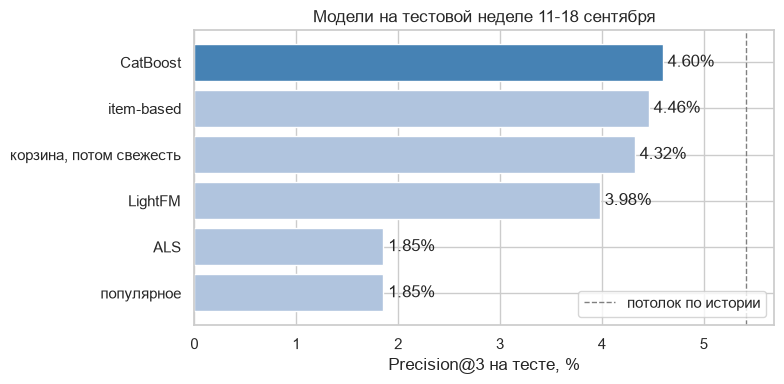

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
order = test_table.sort_values("P@3, %")
colors = [COLOR if name == "CatBoost" else "lightsteelblue" for name in order.index]
ax.barh(order.index, order["P@3, %"], color=colors)
for y, value in enumerate(order["P@3, %"]):
    ax.text(value + 0.05, y, f"{value:.2f}%", va="center")
ax.axvline(
    ceiling.loc[test_cut.date(), "потолок P@3, %"],
    color="gray",
    ls="--",
    lw=1,
    label="потолок по истории",
)
ax.set_xlabel("Precision@3 на тесте, %")
ax.set_title("Модели на тестовой неделе 11-18 сентября")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(REPORTS / "model_comparison.png", dpi=150)
plt.show()

CatBoost лучший и на тесте: 4.6% против 1.85% у популярного, в 2.5 раза больше. До потолка по истории 5.42% остаётся немного. У тёплых покупателей примерно каждый шестой показанный товар потом покупают

Для Марии понятнее доля покупок, которую закрывают рекомендации. Её бейзлайн, топ-3 до июля, закрывал 0.61% покупок после, CatBoost закрывает 7.9% покупок тестовой недели

Разрыв между valid и тестом у всех моделей в одну сторону: на тестовой неделе покупатели чаще брали товары из истории, потолок там выше. Порядок моделей на двух неделях одинаковый, только ALS на тесте совпал с популярным до сотых. Это подозрительно, так что проверил ниже

In [14]:
test_warm = warm_users(test_cut)
test_popular = fallback[test_cut]
hits = pd.DataFrame(
    {
        "ALS": [
            len(set(fill_with(als_test.get(u, []), test_popular)) & bought[test_cut][u])
            for u in test_warm
        ],
        "популярное": [len(set(test_popular) & bought[test_cut][u]) for u in test_warm],
    },
    index=test_warm,
)
print(
    "тёплых покупателей в тесте:",
    len(test_warm),
    "| из них в матрице ALS:",
    len(als_test),
)
print("попаданий у тёплых:", hits.sum().to_dict())
print(
    "у одних и тех же людей:", int(((hits["ALS"] > 0) & (hits["популярное"] > 0)).sum())
)
print(
    "ALS рекомендует популярную тройку:",
    sum(set(items) == set(test_popular) for items in als_test.values()),
    "раз",
)

тёплых покупателей в тесте: 105 | из них в матрице ALS: 65
попаданий у тёплых: {'ALS': 11, 'популярное': 11}
у одних и тех же людей: 4
ALS рекомендует популярную тройку: 0 раз


Совпадение случайное: у обоих по 11 попаданий среди тёплых, но общих людей только четыре, и популярную тройку ALS никому целиком не рекомендует. Просто на тестовой неделе ALS угадал столько же, сколько хиты

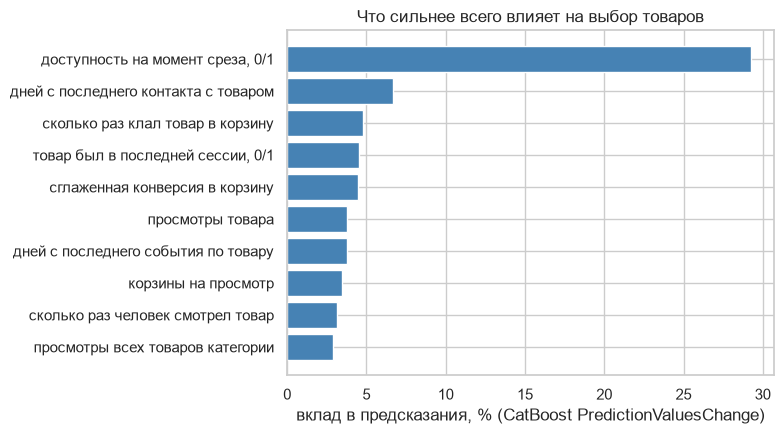

i_available           29.2
ui_days_since_last     6.7
ui_carts               4.8
ui_in_last_session     4.5
i_cart_rate            4.5
i_views                3.8
i_days_since_last      3.8
u_cart_rate            3.5
ui_views               3.2
c_views                2.9
dtype: float64

In [15]:
importance = pd.Series(final_model.get_feature_importance(), index=FEATURES)
importance = importance.sort_values(ascending=False)
importance.rename("важность").to_csv(REPORTS / "feature_importance.csv")

top = importance.head(10)[::-1]
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh([FEATURE_DESC[f] for f in top.index], top.values, color=COLOR)
ax.set_xlabel("вклад в предсказания, % (CatBoost PredictionValuesChange)")
ax.set_title("Что сильнее всего влияет на выбор товаров")
plt.tight_layout()
plt.savefig(REPORTS / "feature_importance.png", dpi=150)
plt.show()
importance.head(10).round(1)

Больше всего модель опирается на наличие товара: то, чего нет на складе, не купят и в корзину не положат, это почти треть вклада. Дальше свежесть контакта человека с товаром, его корзина, был ли товар в последнем визите и как часто этот товар кладут в корзину другие. Номер категории и цена почти не влияют. Если коротко для Марии: рекомендуем то, что есть в наличии, что человек недавно смотрел и откладывал и что хорошо берут другие

<a id="sec-final"></a>

## 9. Модель для сервиса

Для сервиса та же модель с теми же параметрами переобучается на всех шести срезах, тест к этому моменту тоже прошлое. Кандидатов с факторами считаю на конец лога, 18 сентября 03:00, для всех, у кого есть история за 8 недель. Остальным сервис отдаёт популярное

Всё это делает скрипт `build_artifacts.py`, отдельно от ноутбука, чтобы модель можно было пересобрать одной командой из сырых файлов. Он же на всякий случай ещё раз считает P@3 модели, обученной на train, и кладёт цифры в `models/meta.json`. Ниже то, что он сохранил

In [16]:
import json

meta = json.loads(Path("models/meta.json").read_text())
print(
    {
        k: meta[k]
        for k in [
            "model",
            "params",
            "target",
            "serve_cut",
            "users_with_history",
            "candidates",
            "popular",
        ]
    }
)
print("метрики модели на train:", meta["metrics_model_trained_on_train"])

{'model': 'CatBoostClassifier', 'params': {'iterations': 590, 'learning_rate': 0.03, 'depth': 4, 'random_seed': 42}, 'target': 'target_cart', 'serve_cut': '2015-09-18 03:00:00', 'users_with_history': 573765, 'candidates': 807164, 'popular': [461686, 213834, 119736, 248455, 334401, 320130, 546, 312728, 441852, 445351, 9877, 190000, 138427, 420960, 409804, 48030, 268883, 174489, 10572, 7943]}
метрики модели на train: {'valid': {'precision_at_3': 0.0354, 'purchase_coverage': 0.064, 'buyers': 602}, 'test': {'precision_at_3': 0.046, 'purchase_coverage': 0.0791, 'buyers': 486}}


<a id="sec-sum"></a>

## Итоги

Precision@3 считаю по всем покупателям недели, тем, кому персонально показать нечего, добиваю популярным. Потолок задают данные: даже идеальный выбор из истории даёт 3.8% на valid и 5.4% на тесте, потому что большинство покупает то, чего раньше не смотрело

Популярное (топ по покупкам за 8 недель) даёт 1.44% на valid и 1.85% на тесте. Модели, которые предлагают новое вместо истории человека (ALS, LightFM, похожие товары без истории), дают на valid 1.3-2.7%. Простое правило "последнее из истории, корзина вперёд" сразу даёт 3.2%. Лучший результат у CatBoost, который ранжирует товары из истории по 37 факторам: 3.54% на valid и 4.6% на тесте, это 7.9% покупок недели против 0.61% у бейзлайна Марии. Сильнее всего на решение влияют наличие товара, свежесть контакта и корзина

Совет ментора про фильтр малоактивных проверил: для ALS он режет покрытие, почти все посетители тут разовые. Факторы Серёги (время суток, топ-20 свойств) проверил в LightFM и CatBoost, прироста нет

В сервис идёт CatBoost с запасным популярным для холодных. Дальше можно пробовать кандидатов из похожих товаров с отдельным ранжированием и пересчёт рекомендаций внутри визита, когда появится первый просмотр